In [1]:
from IPython.display import Image, HTML, display
image_path = "Logos.jpeg"

img_html = Image(url=image_path, width=800)._repr_html_()

centered_image_html = f"<div style='text-align:center;'>{img_html}</div>"

display(HTML(centered_image_html))

import warnings
warnings.filterwarnings('ignore')

<div style="text-align:center"; font-size: 32px;>
    
# Geospatial data analysis

</div>

**Author:** Naziru Halilu


<span style="font-size:120%">

In this class, we will perform unsupervised classification in Python using a single Planet image and a time series of three images (April, August, and November). This practice will enable students to:
- Load Planet images and prepare them for unsupervised classification.
- Perform unsupervised classification with a single image.
- Assign a label to each land cover class.
- Perform unsupervised classification with a time series and analyze the differences between classifications.

</span>

## Import libraries

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import colors
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
# New library. K-means library
from sklearn.cluster import KMeans

## Load a Planet image

In [3]:
os.getcwd()

'C:\\Users\\alumno\\Desktop\\Topic_5'

In [4]:
# Defines the path to the folder where the rasters are located
data_dir = 'Planet/'

# Use the glob library to find all .tif files in the folder
search_criteria = os.path.join(data_dir, '*.tif')
raster_files = glob.glob(search_criteria)
raster_files

['Planet\\20170408_100633_1005_3B_clip.tif',
 'Planet\\20170821_100613_0e26_3B_clip.tif',
 'Planet\\20171128_101646_1004_3B_clip.tif']

In [5]:
# Read the summer image and print the number of bands
src = rasterio.open(raster_files[1])
print('Number of bands: ',src.count)

Number of bands:  4


In [7]:
try:
   band_descriptions = [src.descriptions[i-1] for i in src.indexes]
   print(f"Band's description: {band_descriptions}")
except IndexError:
   print("No descriptions availables")

Band's description: ['blue', 'green', 'red', 'nir']


In [12]:
print('Max value of first band: ',src.read(1).max())
print('Max value of second band: ',src.read(2).max())
print('Max value of third band: ',src.read(3).max())
print('Max value of forth band: ',src.read(4).max())

Max value of first band:  2940
Max value of second band:  3419
Max value of third band:  4364
Max value of forth band:  5536


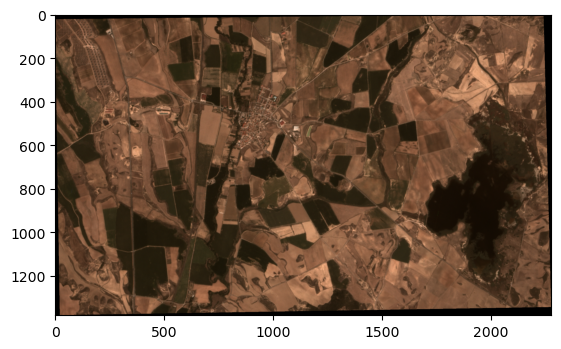

In [14]:
# Read Red band
band_red = src.read(3)/10000
# Read green band
band_green = src.read(2)/10000
# Read blue band
band_blue = src.read(1)/10000
        
# Reads metadata and projection information (useful for saving)
metadata = src.meta
    
# Apply color stretch 
def color_stretch(band, min_val, max_val):
        # Consider the maximum and minimum possible values to avoid outliers
        band = np.clip(band, min_val, max_val)
        # Scale from 0 to 255 (for display)
        band_stretched = ((band - min_val) / (max_val - min_val)) * 255
        return band_stretched.astype(np.uint8)
    
# Defines the cut-off values. 
min_clip = 0  
max_clip = 0.4
    
red_stretched = color_stretch(band_red, min_clip, max_clip)
green_stretched = color_stretch(band_green, min_clip, max_clip)
blue_stretched = color_stretch(band_blue, min_clip, max_clip)
    
# Stack the bands for display
# The final stacking order should be (Red, Green, Blue)
rgb_composite = np.dstack((red_stretched, green_stretched, blue_stretched))
    
# Show
plt.imshow(rgb_composite)
plt.show()


## Data preparation for K-means

In [15]:
# Read only those bands that will be used in the K-means classification
array_comb = src.read([1,2, 3, 4]) 

In [16]:
print(f"Dimensions of the multitemporal array: {array_comb.shape}")

Dimensions of the multitemporal array: (4, 1382, 2279)


To apply the K-means algorithm, the data array must be reformatted. The initial combined array is likely in the format (Bands, Height, Width), but K-means requires that each pixel be treated as a sample and each band as a feature (format: Samples, Features).</br>
</br>
1-	Transpose (.transpose(1, 2, 0)): The array dimensions are rearranged so that they are in the format (Height, Width, Bands). This ensures that the Bands dimension is placed last.

2-	Flattening (.reshape(-1, n_features)): The Height and Width dimensions are flattened into a single Samples dimension (all pixels), while maintaining the number of bands (n_features) equal to the number of Features (columns).


In [17]:
n_features = array_comb.shape[0] 
data_reshaped = array_comb.transpose(1, 2, 0).reshape(-1, n_features) 

In [18]:
print('The number of bands/layers: ',n_features)
print('New dimensions: ',data_reshaped.shape)

The number of bands/layers:  4
New dimensions:  (3149578, 4)


In [19]:
# Handling null or "No Data" values (optional but recommended)
# This is crucial to prevent K-Means from being confused by "No Data" values
# It is assumed that NaN (or zero) values should be excluded from clustering
mask_valid = np.all(data_reshaped != 0, axis=1) # Create a mask for valid pixels
data_valid = data_reshaped[mask_valid]

In [20]:
print('Dimensions: ',data_valid.shape)

Dimensions:  (3045836, 4)


## K-means

In [21]:
# Apply K-Means
# Define the number of classes (clusters) you want to identify
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=30)

# Train the model ONLY with valid pixels
kmeans.fit(data_valid)

# Get the cluster labels (the classification result)
valid_labels = kmeans.labels_

In [24]:
valid_labels.min()

0

In [25]:
# Create an empty result array for the entire map
w=src.width
h=src.height
profile=src.profile
# Customize the labels of the no data
map_labels =np.full((h, w), 10, dtype=np.int32)
map_labels=map_labels.flatten()

# Assign cluster labels only to valid pixels
map_labels[mask_valid.flatten()] = valid_labels

# Reshape the array to match the dimensions of the original map
final_labes = map_labels.reshape(h, w)

# Export the GeoTIFF result
profile.update(dtype=rasterio.int32, count=1, nodata=10, compress='lzw')

with rasterio.open('classification_kmeans_ts6.tif', 'w', **profile) as dst:
    dst.write(final_labes.astype(rasterio.int32),1)

print("Unsupervised classification completed and exported as'classification_kmeans_ts6.tif'")

Unsupervised classification completed and exported as'classification_kmeans_ts6.tif'


In [26]:
path_class=r'classification_kmeans_ts6.tif'

with rasterio.open(path_class) as src:
    class_array = src.read(1)
    nodata_value = src.nodata if src.nodata is not None else 10 

# # We exclude NoData=10
class_real = np.unique(class_array[class_array != 10])
num_classes = len(class_real) 


In [27]:
num_classes

6

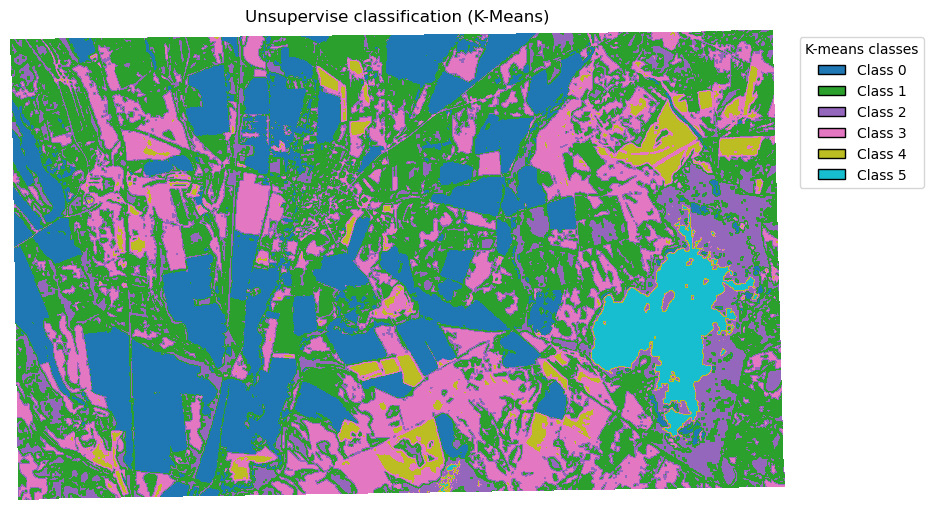

In [28]:
# ----------------------------------------------------------------------
# DISCRETE NORMALIZATION
# ----------------------------------------------------------------------
# Define the edges: From 0 to N classes + 1
bounds = np.arange(num_classes + 1)

# Create the Colormap (use the exact number of classes)
cmap_class = plt.cm.get_cmap('tab10', num_classes)

# Create boundary normalization: Assign each integer to the color of its 'box'
norm = colors.BoundaryNorm(bounds, cmap_class.N) 

# Mask No Data to transparent for display
# cmap_class.set_bad(color='black', alpha=0) 
masked_array = np.ma.masked_equal(class_array, nodata_value)

# --- Display and legend ---
fig, ax = plt.subplots(figsize=(10, 10))

# Displays the classification using Normalization
# This ensures that only the 5 exact colors from the color map are used
im = ax.imshow(masked_array, cmap=cmap_class, norm=norm) 

# We define the names of the classes (Class 1 to Class 5)
class_names = [f'Class {j}' for j in class_real] 

# Create the Patch list for the legend
legend_patch = []
# We iterate over the color map index.
for i in range(num_classes):
    patch = Patch(facecolor=cmap_class(i), edgecolor='black', label=class_names[i])
    legend_patch.append(patch)

# Add legend
ax.legend(handles=legend_patch, 
          title='K-means classes', 
          loc='upper left', 
          bbox_to_anchor=(1.01, 1), 
          fontsize=10)

ax.set_title('Unsupervise classification (K-Means)')
ax.axis('off')
plt.show()


## Spectral signature

In [29]:
spectral_signature = {}

# Iterate over each class (from 0 to n_clusters - 1)
for class_id in range(n_clusters):
    # Create a boolean mask: True where label corresponds to the current class_id
    class_mask = (valid_labels == class_id)
    
    # Select ONLY the pixels that belong to that class
    class_data = data_valid[class_mask]
    
    # Calculate the mean value for EACH BAND (along the 0 axis, i.e. the pixel axis)
    mean_per_band = np.mean(class_data, axis=0)
    
    # Store the result
    spectral_signature[f'Class_{class_id}'] = mean_per_band

# Convert the result to a Pandas DataFrame for better visualization:
df_signature = pd.DataFrame(spectral_signature).T 

In [30]:
df_signature

,0,1,2,3
Class_0,298.797001,568.420392,727.079362,3652.551968
Class_1,776.263493,1139.647433,1658.733011,2580.609032
Class_2,480.039980,765.954935,1105.180445,2179.321833
Class_3,1046.227256,1473.473430,2145.226452,2829.101627
Class_4,1471.905113,2015.351879,2853.506576,3323.605258
Class_5,105.558779,267.372862,427.827171,560.672013


In [31]:
# Rename columns to make it more intuitive
band_name = ['Blue', 'Green', 'Red', 'NIR'] 
df_signature.columns = band_name

df_signature


,Blue,Green,Red,NIR
Class_0,298.797001,568.420392,727.079362,3652.551968
Class_1,776.263493,1139.647433,1658.733011,2580.609032
Class_2,480.039980,765.954935,1105.180445,2179.321833
Class_3,1046.227256,1473.473430,2145.226452,2829.101627
Class_4,1471.905113,2015.351879,2853.506576,3323.605258
Class_5,105.558779,267.372862,427.827171,560.672013


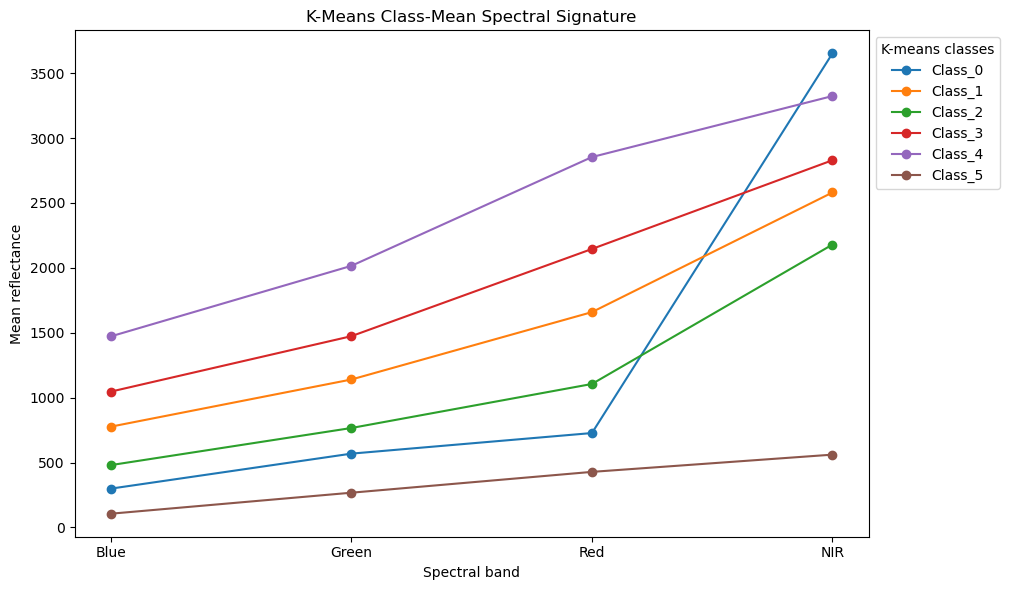

In [32]:
#Plot the spectral signature of all k-means
plt.figure(figsize=(12, 6))

for class_n in df_signature.index:
    # Get the reflectance values of the current class
    reflectances = df_signature.loc[class_n, band_name]
    
    # Graph the line
    plt.plot(band_name, reflectances, marker='o', linestyle='-', linewidth=1.5,label=class_n)   

    
plt.title('K-Means Class-Mean Spectral Signature')
plt.xlabel('Spectral band')
plt.ylabel('Mean reflectance')
plt.legend(title='K-means classes', loc='upper left', bbox_to_anchor=(1, 1)) 
plt.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()

# Time Series

<span style="font-size:120%">

Using a time series significantly improves land cover (and especially crop) classification, as K-means uses phenological differences (color changes over time) to better distinguish classes that are spectrally similar on a single date. Unsupervised classification using K-means requires data preparation (creation of the multitemporal array) by combining the bands from the different images into a single data structure. In this case, we will work with three images: one from April, one from August, and one from November. Since Planet has 4 bands per image, the final array will have 3 images × 4 bands = 12 layers.

</span>

In [33]:
os.chdir('Planet/')

In [34]:
os.getcwd()

'C:\\Users\\alumno\\Desktop\\Topic_5\\Planet'

In [35]:
os.listdir()

['20170408_100633_1005_3B_clip.tif',
 '20170821_100613_0e26_3B_clip.tif',
 '20171128_101646_1004_3B_clip.tif']

In [36]:
# Paths of your Planet images for the 3 dates
path = ['20170408_100633_1005_3B_clip.tif','20170821_100613_0e26_3B_clip.tif','20171128_101646_1004_3B_clip.tif']
array_comb = []

# Read all bands of each image and stack them
for r in path:
    with rasterio.open(r) as src:      
        # Assuming you want the 4 main Planet bands: B, G, R, NIR
        # Indexes may vary, adjust them according to your .tif file
        bands = src.read([1, 2, 3, 4]) 
        print(bands.shape)
        array_comb.append(bands)
        
        # Saves the dimensions and metadata of the first image for export
        if r == path[0]:
            profile = src.profile
            w = src.width
            h = src.height

# Joins all band arrays along the 0 axis (depth/bands)
data_multitemporal = np.concatenate(array_comb, axis=0)

# The final array will have dimensions (Total_Number_of_Bands_x_Height_x_Width)
print(f"Dimensiones del array multitemporal: {data_multitemporal.shape}")

(4, 1382, 2279)
(4, 1382, 2279)
(4, 1382, 2279)
Dimensiones del array multitemporal: (12, 1382, 2279)


<span style="font-size:120%">
K-Means expects a matrix where each row is a sample (a pixel) and each column is a feature (a band/layer).
Currently, you have a 3D array: (Bands, Height, Width). You need to transform it into a 2D array: (Pixels, Features). We repeat the procedure with a single image.

- Change the array's shape using .reshape()
- Mask out the missing data
- Set the K-means algorithm parameters
- Train the model
- Obtain the labels for each pixel
</span>

In [38]:
# Change the array's shape using .reshape()
n_features = data_multitemporal.shape[0] 
data_reshaped = data_multitemporal.transpose(1, 2, 0).reshape(-1, n_features) 
data_reshaped.shape

(3149578, 12)

In [ ]:
# Mask out the missing data
data_valid = data_reshaped[mask_valid]
# Set the K-means algorithm parameters
n_clusters = 6 
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=30)
# Train the model
kmeans.fit(data_valid)
# Obtain the labels for each pixel
valid_labels = kmeans.labels_

In [39]:
# Create an empty result array for the entire map
map_labels =np.full((h, w), 10, dtype=np.int32)
map_labels=map_labels.flatten()

# Assign cluster labels only to valid pixels
map_labels[mask_valid.flatten()] = valid_labels

# Reshape the array to match the dimensions of the original map
final_labes = map_labels.reshape(h, w)

# Export the GeoTIFF result
profile.update(dtype=rasterio.int32, count=1, nodata=10, compress='lzw')

with rasterio.open('classification_kmeans_ts_3_images.tif', 'w', **profile) as dst:
    dst.write(final_labes, 1)

print("Unsupervised classification completed and exported as 'classification_kmeans_ts_3_images.tif'")

Unsupervised classification completed and exported as 'clasification_kmeans_ts_3_images.tif'


In [42]:
os.getcwd()

'C:\\Users\\alumno\\Desktop\\Topic_5\\Planet'

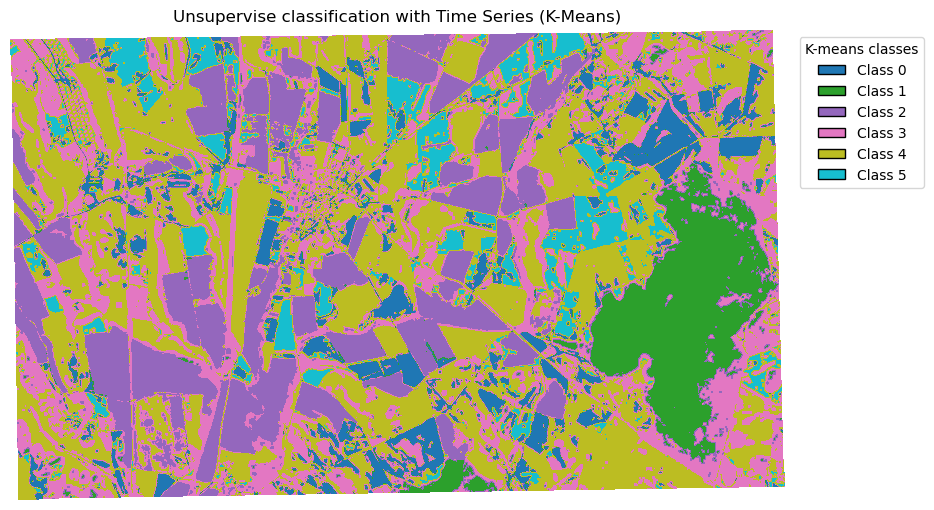

In [43]:
path_class=r'classification_kmeans_ts_3_images.tif'

with rasterio.open(path_class) as src:
    class_array = src.read(1)
    nodata_value = src.nodata if src.nodata is not None else 0 

# We exclude NoData=0
clases_reales = np.unique(class_array[class_array != nodata_value])
num_classes = len(clases_reales) 
# ----------------------------------------------------------------------
# DISCRETE NORMALIZATION
# ----------------------------------------------------------------------
# Define the edges: From 0 to N classes + 1
bounds = np.arange(num_classes + 1)

# Create the Colormap (use the exact number of classes)
cmap_class = plt.cm.get_cmap('tab10', num_classes)

# Create boundary normalization: Assign each integer to the color of its 'box'
norm = colors.BoundaryNorm(bounds, cmap_class.N) 

# Mask No Data to transparent for display
# cmap_class.set_bad(color='black', alpha=0) 
masked_array = np.ma.masked_equal(class_array, nodata_value)

# --- Display and legend ---
fig, ax = plt.subplots(figsize=(10, 10))

# Displays the classification using Normalization
# This ensures that only the 5 exact colors from the color map are used
im = ax.imshow(masked_array, cmap=cmap_class, norm=norm) 

# We define the names of the classes (Class 1 to Class 5)
class_names = [f'Class {j}' for j in class_real] 

# Create the Patch list for the legend
legend_patch = []
# We iterate over the color map index.
for i in range(num_classes):
    patch = Patch(facecolor=cmap_class(i), edgecolor='black', label=class_names[i])
    legend_patch.append(patch)

# Add legend
ax.legend(handles=legend_patch, 
          title='K-means classes', 
          loc='upper left', 
          bbox_to_anchor=(1.01, 1), 
          fontsize=10)


ax.axis('off')
ax.set_title('Unsupervise classification with Time Series (K-Means)')

plt.show()

In [44]:
spectral_signature = {}

# Iterate over each class (from 0 to n_clusters - 1)
for class_id in range(n_clusters):
    # Create a boolean mask: True where label corresponds to the current class_id
    class_mask = (valid_labels == class_id)
    
    # Select ONLY the pixels that belong to that class
    class_data = data_valid[class_mask]
    
    # Calculate the mean value for EACH BAND (along the 0 axis, i.e. the pixel axis)
    mean_per_band = np.mean(class_data, axis=0)
    
    # Store the result
    spectral_signature[f'Clase_{class_id}'] = mean_per_band

# Convert the result to a Pandas DataFrame for better visualization:
df_signature = pd.DataFrame(spectral_signature).T 

In [45]:
df_signature

,0,1,2,3,4,5,6,7,8,9,10,11
Clase_0,994.707478,1528.456902,2046.964769,3811.071649,1325.315915,1827.483265,2595.805789,3133.485292,884.745610,1430.037506,1958.113395,2552.298141
Clase_1,113.813914,328.228623,471.325608,1051.568559,220.008963,424.072712,619.568515,1300.869806,256.268276,580.391520,815.826291,1100.197180
Clase_2,797.416161,1285.296251,1792.241130,3294.072410,291.619975,558.878439,713.822103,3685.563871,605.934577,1068.979066,1518.701036,2181.365029
Clase_3,397.830489,738.350047,961.593506,2809.032913,572.760735,879.765018,1268.464389,2288.309978,419.829774,800.813434,1085.197387,1901.044980
Clase_4,291.252840,629.167921,747.264209,4414.868981,891.329757,1284.669780,1876.067864,2790.764958,676.235103,1151.940341,1587.684582,2294.388928
Clase_5,799.949338,1267.866400,1733.290416,3315.690197,846.762323,1230.331326,1779.697144,2703.972402,645.250148,1105.885385,1527.745269,2259.674001


In [46]:
# Rename columns to make it more intuitive
band_name = ['Blue_Apr', 'Green_Apr', 'Red_Apr', 'NIR_Apr','Blue_Aug', 'Green_Aug', 'Red_Aug', 'NIR_Agu','Blue_Nov', 'Green_Nov', 'Red_Nov', 'NIR_Nov'] 
df_signature.columns = band_name

df_signature

,Blue_Apr,Green_Apr,Red_Apr,NIR_Apr,Blue_Aug,Green_Aug,Red_Aug,NIR_Agu,Blue_Nov,Green_Nov,Red_Nov,NIR_Nov
Clase_0,994.707478,1528.456902,2046.964769,3811.071649,1325.315915,1827.483265,2595.805789,3133.485292,884.745610,1430.037506,1958.113395,2552.298141
Clase_1,113.813914,328.228623,471.325608,1051.568559,220.008963,424.072712,619.568515,1300.869806,256.268276,580.391520,815.826291,1100.197180
Clase_2,797.416161,1285.296251,1792.241130,3294.072410,291.619975,558.878439,713.822103,3685.563871,605.934577,1068.979066,1518.701036,2181.365029
Clase_3,397.830489,738.350047,961.593506,2809.032913,572.760735,879.765018,1268.464389,2288.309978,419.829774,800.813434,1085.197387,1901.044980
Clase_4,291.252840,629.167921,747.264209,4414.868981,891.329757,1284.669780,1876.067864,2790.764958,676.235103,1151.940341,1587.684582,2294.388928
Clase_5,799.949338,1267.866400,1733.290416,3315.690197,846.762323,1230.331326,1779.697144,2703.972402,645.250148,1105.885385,1527.745269,2259.674001


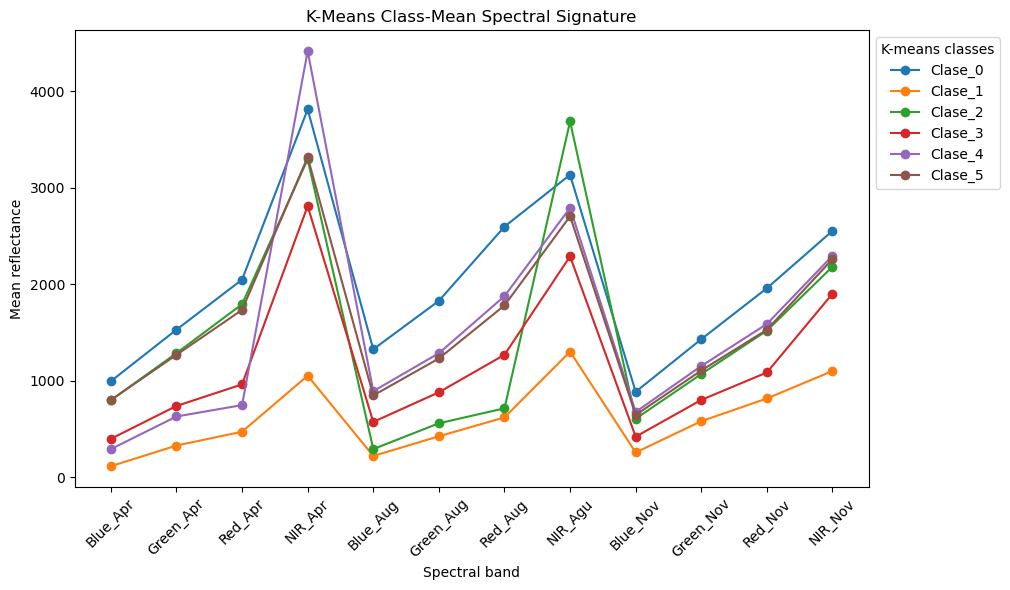

In [47]:
#Plot the spectral signature of all k-means
plt.figure(figsize=(12, 6))

for class_n in df_signature.index:
    # Get the reflectance values of the current class
    reflectances = df_signature.loc[class_n, band_name]
    
    # Graph the line
    plt.plot(band_name, reflectances, marker='o', linestyle='-', linewidth=1.5,label=class_n)   

    
plt.title('K-Means Class-Mean Spectral Signature')
plt.xlabel('Spectral band')
plt.ylabel('Mean reflectance')
plt.xticks(rotation=45)
plt.legend(title='K-means classes', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1]) 


plt.show()